In [1]:
# ── Cell 1
# Core utilities
import os
import time
import warnings
import random
from argparse import Namespace

# Data & Numerical Computing
import numpy as np

# Plotting & Visualization
import matplotlib.pyplot as plt

# JAX Framework
import jax
import jax.numpy as jnp
from jax import random as jax_random


# ─────────────────────────────────────────────────────────────────────────────
# Global Configuration & Seeding
# ─────────────────────────────────────────────────────────────────────────────

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'ggplot')

# Global JAX random key (used across all cells, including main())
JAX_KEY = None

def seed_everything(seed=42):
    """Set global seed for reproducibility across NumPy, Python random, and JAX."""
    global JAX_KEY
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    JAX_KEY = jax_random.PRNGKey(seed)

# Initialize global seed (this JAX_KEY will be used in main() function)
seed_everything(42)

def rk4_step(q, dynamics_fn, dt):
    """Perform a single RK4 integration step.

    Args:
        q: Current state
        dynamics_fn: Function that computes state derivatives
        dt: Time step

    Returns:
        q_new: Updated state after RK4 step
        deriv: Derivative at current state
    """
    k1 = dynamics_fn(q)
    k2 = dynamics_fn(q + 0.5 * dt * k1)
    k3 = dynamics_fn(q + 0.5 * dt * k2)
    k4 = dynamics_fn(q + dt * k3)

    q_new = q + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)
    deriv = dynamics_fn(q)  # Derivative at current state

    return q_new, deriv

# ─────────────────────────────────────────────────────────────────────────────
# JIGSAWS Dataset Directory Resolution
# ─────────────────────────────────────────────────────────────────────────────
from pathlib import Path

# 1. Safely mount Google Drive ONLY if running in Google Colab
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    pass  # Ignores the error if running on Kaggle or locally

# 2. Define potential paths using modern pathlib syntax (cleaner than os.path.join)
cwd = Path.cwd()
candidates = [
    Path('/content/drive/MyDrive/JIGSAWS/Suturing/Suturing'),
    cwd / 'JIGSAWS_datasets' / 'JIGSAWS' / 'Suturing' / 'Suturing',
    cwd / 'JIGSAWS' / 'Suturing' / 'Suturing',
    cwd / 'Suturing' / 'Suturing'
]

# 3. Find the first valid directory using a clean generator expression
JIGSAWS_ROOT = next((path for path in candidates if path.is_dir()), None)

if JIGSAWS_ROOT is None:
    raise FileNotFoundError("Could not find JIGSAWS_ROOT in any candidate paths.")

print(f'JIGSAWS_ROOT = {JIGSAWS_ROOT}')

# ─────────────────────────────────────────────────────────────
print('✓ All required libraries imported and configured.')

Mounted at /content/drive
JIGSAWS_ROOT = /content/drive/MyDrive/JIGSAWS/Suturing/Suturing
✓ All required libraries imported and configured.


In [2]:
# ── Cell 2
# JIGSAWS data-loading utilities — interaction-only ──────────────
import numpy as np
import jax.numpy as jnp
from jax import jit
from pathlib import Path

DT = 1.0 / 30.0  # 30 Hz
H_DATA_GEN = DT
FPS = 30

# ── Hand-annotated needle-tissue interaction intervals (seconds) ──────────────
INTERACTION_TIMES = {
    'B001': [(0,10),(23,32),(38,47),(60,79),(92,102),(124,135),(147,160),(169,180)],
    'B002': [(20,30),(47,60),(70,90),(100,109)],
    'B003': [(1,5),(10,20),(34,43),(52,70),(80,100)],
    'B004': [(5,25),(38,49),(59,75),(89,100)],
    'B005': [(16,34),(42,50),(62,72),(79,87)],
    'C001': [(13,26),(44,57),(70,76),(87,94)],
    'C002': [(15,28),(43,50),(63,71),(82,95)],
    'C003': [(15,24),(38,45),(56,65),(75,85),(100,102)],
    'C004': [(10,17),(29,37),(48,54),(63,70)],
    'C005': [(9,14),(23,30),(45,52),(59,74)],
    'D001': [(13,19),(38,52),(63,70),(78,88)],
    'D002': [(6,14),(24,31),(40,45),(54,62)],
    'D003': [(9,16),(25,33),(48,54),(60,73)],
    'D004': [(11,17),(26,31),(47,54),(77,83)],
    'D005': [(9,15),(23,29),(37,43),(50,55)],
    'E001': [(9,23),(25,32),(62,74),(89,98)],
    'E002': [(9,23),(36,44),(54,61),(70,80)],
    'E003': [(9,17),(24,33),(44,51),(62,69)],
    'E004': [(8,20),(30,39),(50,58),(74,82)],
    'E005': [(5,14),(24,32),(41,49),(58,64)],
    'F001': [(9,18),(32,40),(49,58),(71,81)],
    'F002': [(6,15),(26,35),(45,52),(59,68)],
    'F003': [(8,14),(23,24),(41,48),(56,62)],
    'F004': [(7,15),(23,29),(43,53),(63,69)],
    'F005': [(4,14),(22,26),(37,41),(51,57)],
    'G001': [(17,29),(49,85),(91,107),(121,146),(162,193),(211,292)],
    'G002': [(10,20),(29,45),(55,63),(74,103)],
    'G003': [(17,29),(38,47),(58,65),(92,112),(152,164)],
    'G004': [(16,24),(34,41),(50,58),(70,77)],
    'G005': [(8,17),(26,33),(41,55),(64,72)],
    'H001': [(24,51),(67,81),(128,135),(152,164)],
    'H003': [(18,33),(50,58),(71,83),(94,101)],
    'H004': [(15,24),(44,55),(80,91),(111,121)],
    'H005': [(14,24),(35,39),(88,91),(92,101)],
    'I001': [(16,31),(45,57),(72,85),(119,132)],
    'I002': [(22,42),(58,81),(100,112),(127,142)],
    'I003': [(27,44),(58,79),(99,116),(127,135)],
    'I004': [(18,37),(50,64),(84,98),(111,118)],
    'I005': [(22,42),(58,68),(83,96),(110,124)],
}

def make_mask(trial_key, num_frames, fps=FPS):
    """Bool mask (T,): True = needle-tissue interaction frame."""
    mask = np.zeros(num_frames, dtype=bool)
    for (t0, t1) in INTERACTION_TIMES.get(trial_key, []):
        f0, f1 = max(0, int(round(t0 * fps))), min(num_frames - 1, int(round(t1 * fps)))
        mask[f0:f1 + 1] = True
    return mask

def _contiguous_segments(mask):
    """List of (start, end) frame-index pairs for each True run in mask."""
    # Cleaner state tracking
    diffs = np.diff(np.concatenate([[0], mask.view(np.int8), [0]]))
    starts = np.where(diffs == 1)[0]
    ends = np.where(diffs == -1)[0]
    return list(zip(starts, ends))

def _parse_meta(meta_path):
    with open(meta_path) as fh:
        return {p[0]: p[1] for line in fh if len(p := line.strip().split()) >= 2}

@jit
def _rotmat_to_rotvec_batch_jax(R):
    """Convert batch of 3x3 rotation matrices to axis-angle rotation vectors (JAX Compiled)."""
    tr = jnp.trace(R, axis1=1, axis2=2)
    cos_th = jnp.clip((tr - 1.0) * 0.5, -1.0, 1.0)
    th = jnp.arccos(cos_th)

    v = jnp.stack([
        R[:, 2, 1] - R[:, 1, 2],
        R[:, 0, 2] - R[:, 2, 0],
        R[:, 1, 0] - R[:, 0, 1],
    ], axis=1)

    # JAX arrays are immutable, so we use jnp.where instead of boolean array assignments
    small_angle_mask = (th < 1e-6)[:, None]

    s = jnp.sin(th)[:, None]
    axis = v / jnp.clip(2.0 * s, 1e-8, None)

    rv_small = 0.5 * v  # First-order approximation near zero
    rv_large = axis * th[:, None]

    return jnp.where(small_angle_mask, rv_small, rv_large)

def _load_trial_file(path):
    arr = np.loadtxt(path, dtype=np.float32)
    if arr.ndim == 1:
        arr = arr[None, :]
    if arr.shape[1] < 56:
        raise ValueError(f'Unexpected kinematics shape {arr.shape} in {path}')

    # Send values to JAX
    pos     = jnp.array(arr[:, 38:41])
    R       = jnp.array(arr[:, 41:50]).reshape(-1, 3, 3)
    rotvec  = _rotmat_to_rotvec_batch_jax(R)
    lin_vel = jnp.array(arr[:, 50:53])
    ang_vel = jnp.array(arr[:, 53:56])

    q     = jnp.concatenate([pos, rotvec], axis=-1)   # (T,6)
    q_dot = jnp.concatenate([lin_vel, ang_vel], axis=-1)
    return q, q_dot

def load_suturing_interaction(root, skill=None, subjects=None):
    root_path = Path(root)
    meta = _parse_meta(root_path / 'meta_file_Suturing.txt')
    kin_dir = root_path / 'kinematics' / 'AllGestures'

    trials = []
    # Using pathlib.glob for cleaner directory parsing
    for file_path in sorted(kin_dir.glob('*.txt')):
        name = file_path.stem
        sk = meta.get(name)
        if not sk:
            continue

        subj = name.split('_')[-1][0]
        if (subjects and subj not in subjects) or (skill and sk != skill):
            continue

        q, qd = _load_trial_file(file_path)
        states = jnp.concatenate([q, qd], axis=-1)

        trial_key = name.replace('Suturing_', '')
        mask = make_mask(trial_key, len(states))

        for si, (s, e) in enumerate(_contiguous_segments(mask)):
            seg = states[s:e]
            if len(seg) >= 2:
                trials.append({
                    'name': f'{name}_s{si:02d}', 'subject': subj, 'skill': sk,
                    'states': seg, 'length': len(seg), 'trial': name, 'seg_idx': si
                })
    return trials

def build_transitions(trials):
    """One-step transitions from segmented trials: (x_t, x_{t+1})."""
    xt   = jnp.concatenate([t['states'][:-1] for t in trials], axis=0)
    xtp1 = jnp.concatenate([t['states'][1:] for t in trials], axis=0)
    return xt, xtp1

def build_sequences(trials, K=5):
    """K-step sequences for rollout curriculum using list comprehensions."""
    xs, ys = [], []
    for t in trials:
        s = t['states']
        T_ = len(s)
        xs.extend([s[i] for i in range(T_ - K)])
        ys.extend([s[i + 1 : i + K + 1] for i in range(T_ - K)])

    return jnp.array(xs), jnp.array(ys)

print('✓ Interaction-only data utilities compiled in JAX (6-DOF).')

✓ Interaction-only data utilities compiled in JAX (6-DOF).


In [3]:
# ── Cell 3: Generate Data & LOUO Split (TRAIN = EXPERT) ──────────────
LOUO_TEST_SUBJECT = None  # None defaults to the last expert subject

print('Loading JIGSAWS Suturing — INTERACTION segments only ...')

# 1. Load segments (Standard Python dictionaries)
nov_segs = sorted(load_suturing_interaction(JIGSAWS_ROOT, skill='N'), key=lambda x: x['name'])
exp_segs = sorted(load_suturing_interaction(JIGSAWS_ROOT, skill='E'), key=lambda x: x['name'])

# 2. Extract unique expert subjects
expert_subjects = sorted({s['subject'] for s in exp_segs})
test_subject = LOUO_TEST_SUBJECT or expert_subjects[-1]

# 3. LOUO split on EXPERTS
exp_train = [s for s in exp_segs if s['subject'] != test_subject]
exp_test  = [s for s in exp_segs if s['subject'] == test_subject]

# 4. Build JAX Arrays (Keeping x_tr variable name so training cell doesn't break)
x_tr, y_tr = build_transitions(exp_train)
x_et, y_et = build_transitions(exp_test)        # Expert test (In-distribution)
x_nt, y_nt = build_transitions(nov_segs)        # Novice test (Out-of-distribution)

# 5. Output summary
print('\n✓ JIGSAWS Suturing Data (Train=Expert, OOD=Novice):')
print(f"  Split Subject: '{test_subject}' (Expert Leave-One-User-Out)")
print(f"  Train (Expert) : {x_tr.shape[0]:>6,} transitions | {x_tr.shape[0]/FPS:>6.1f}s")
print(f"  Test (Expert)  : {x_et.shape[0]:>6,} transitions | {x_et.shape[0]/FPS:>6.1f}s")
print(f"  Test (Novice)  : {x_nt.shape[0]:>6,} transitions | {x_nt.shape[0]/FPS:>6.1f}s")

# ─────────────────────────────────────────────────────────────────────────────
# 4. LOUO Split Stats
# ─────────────────────────────────────────────────────────────────────────────
longest  = max(exp_train, key=lambda t: t['length'])
shortest = min(exp_train, key=lambda t: t['length'])

train_subjects = sorted({s['subject'] for s in exp_train})

print(f'\n── LOUO split (interaction frames) ──')
print(f'  Train subjects : {train_subjects} → {len(exp_train):2d} segs | '
      f'{x_tr.shape[0]:>6,} transitions | {x_tr.shape[0]/FPS:>6.1f}s')
print(f'  Test subject   : {test_subject}             → {len(exp_test):2d} segs | '
      f'{x_et.shape[0]:>6,} transitions | {x_et.shape[0]/FPS:>6.1f}s')
print(f'  Novice (OOD)   :                {len(nov_segs):2d} segs | '
      f'{x_nt.shape[0]:>6,} transitions | {x_nt.shape[0]/FPS:>6.1f}s')

print(f'  Longest train seg : {longest["name"]:22s}  {longest["length"]:4d} frames = {longest["length"]/FPS:.1f}s')
print(f'  Shortest train seg: {shortest["name"]:22s}  {shortest["length"]:4d} frames = {shortest["length"]/FPS:.1f}s')

Loading JIGSAWS Suturing — INTERACTION segments only ...

✓ JIGSAWS Suturing Data (Train=Expert, OOD=Novice):
  Split Subject: 'E' (Expert Leave-One-User-Out)
  Train (Expert) :  4,380 transitions |  146.0s
  Test (Expert)  :  5,400 transitions |  180.0s
  Test (Novice)  : 34,950 transitions | 1165.0s

── LOUO split (interaction frames) ──
  Train subjects : ['D'] → 20 segs |  4,380 transitions |  146.0s
  Test subject   : E             → 20 segs |  5,400 transitions |  180.0s
  Novice (OOD)   :                84 segs | 34,950 transitions | 1165.0s
  Longest train seg : Suturing_D001_s01        421 frames = 14.0s
  Shortest train seg: Suturing_D002_s02        151 frames = 5.0s


In [4]:
# ── Cell 4
import flax.linen as nn

DOF = 1           # Degrees of freedom (x, y, z, roll, pitch, yaw)
H   = 1.0/30.0    # DT for JIGSAWS dataset
EPS = 1e-3        # Mass matrix regularization

# ─────────────────────────────────────────────────────────────────────────────
# 1) Lagrangian Network (L-net)
# ─────────────────────────────────────────────────────────────────────────────
class LagrangianNet(nn.Module):
    """
    Lagrangian Network: Maps (q, q̇) → scalar Lagrangian L = T - U

    Architecture (from GLNN paper Section 4.2):
      - 3-layer fully connected network
      - Hidden dimension: 200
      - Activation: Softplus
      - Output initialization: N(0, 1e-4)
    """
    hidden_dim: int = 200

    @nn.compact
    def __call__(self, q, q_t):
        # Concat q and q_dot
        x = jnp.concatenate([q, q_t], axis=-1)

        # Hidden layers with Softplus activation
        x = nn.Dense(self.hidden_dim)(x)
        x = jax.nn.softplus(x)
        x = nn.Dense(self.hidden_dim)(x)
        x = jax.nn.softplus(x)

        # Output layer: scalar Lagrangian
        # Weight ~ N(0, 1e-4), Bias = 0.0
        x = nn.Dense(
            features=1,
            kernel_init=jax.nn.initializers.normal(stddev=1e-6),
            bias_init=jax.nn.initializers.constant(0.0)
        )(x)

        return jnp.squeeze(x, axis=-1)

# ─────────────────────────────────────────────────────────────────────────────
# 2) Force Library Network (replaces ForceNet)
# ─────────────────────────────────────────────────────────────────────────────
class ForceLibraryNet(nn.Module):
    """
    Force Library Network: Combines physics-inspired force terms via a linear layer.

    Features (φ):
      1. q              → Position/spring forces
      2. q̇             → Velocity-dependent forces
      3. tanh(10*q̇)    → Smooth approximation of sign(q̇) for Coulomb friction
      4. M⁻¹∇_qL       → Contribution from Lagrangian gradient

    Output: w·φ + b (scalar force for each DOF)
    """
    output_dim: int = 1

    @nn.compact
    def __call__(self, q, q_t, l_grad_q, l_hess_q_t_q_t):
        """
        Compute non-conservative force from physics-informed library features.

        Args:
            q: Position
            q_t: Velocity
            l_grad_q: Gradient of Lagrangian w.r.t. position
            l_hess_q_t_q_t: Hessian of Lagrangian w.r.t. velocity

        Returns:
            Force prediction shape (..., output_dim)
        """
        # ───────────────────────────────────────────────────────────────────
        # Construct Force Library Features (φ)
        # ───────────────────────────────────────────────────────────────────

        # 1. Position term
        phi_q = q

        # 2. Velocity term
        phi_q_dot = q_t

        # 3. Smooth sign approximation (Coulomb friction)
        phi_q_sign = jnp.tanh(10.0 * q_t)

        # 4. M⁻¹ ∇_q L term
        mass_matrix = l_hess_q_t_q_t
        m_inv = jnp.linalg.pinv(mass_matrix)
        phi_m_inv_dL_dq = jnp.einsum('...ij,...j->...i', m_inv, l_grad_q)

        # Concatenate all library terms: φ = [q, q̇, tanh(10*q̇), M⁻¹∇_qL]
        phi = jnp.concatenate([phi_q, phi_q_dot, phi_q_sign, phi_m_inv_dL_dq], axis=-1)

        # ───────────────────────────────────────────────────────────────────
        # Apply Linear Combiner to Library Features
        # ───────────────────────────────────────────────────────────────────

        # F_nc = w·φ + b (linear combiner on library features)
        x = nn.Dense(
            features=self.output_dim,
            kernel_init=jax.nn.initializers.normal(stddev=1e-6),
            bias_init=jax.nn.initializers.constant(0.0),
            name='force_combiner'  # <--- ADD THIS NAME
        )(phi)
        return x

# ─────────────────────────────────────────────────────────────────────────────
# 3) Hybrid GLNN with both L-net and F-net
# ─────────────────────────────────────────────────────────────────────────────
class HybridGLNNMASS:
    """
    Generalized Lagrangian Neural Network (GLNN) for non-conservative systems.
    Implements the generalized Lagrange equation:
        q̈ = (∇q̇∇_q̇ L)^(-1) [∇_q L - (∇_q∇_q̇ L) @ q̇ + F_nc]
    where:
      - L: Lagrangian learned by L-net
      - F_nc: Non-conservative forces from a physics-informed library:
              F_nc = w·[q, q̇, tanh(10*q̇), M⁻¹∇_qL] + b (clamped to [-10, 10])
    """
    def __init__(self, d, hidden_dim=200, total_systems=5):
        self.d = d
        self.total_systems = total_systems
        self.l_net = LagrangianNet(hidden_dim=hidden_dim)
        self.force_lib_net = ForceLibraryNet(output_dim=d)

    def init(self, key, dummy_x):
        """Initialize L-net and Force Library Network parameters deterministically."""

        # ── 1. THE FIX: Deterministic Key Generation ─────────────────────────────
        # Instead of jax.random.split, we vmap fold_in over the system indices.
        # System 'i' always gets the exact same key, regardless of self.total_systems.
        indices = jnp.arange(self.total_systems)
        keys = jax.vmap(lambda i: jax.random.fold_in(key, i))(indices)
        # ─────────────────────────────────────────────────────────────────────────

        # Extract one sample for initialization
        q, q_t = jnp.split(dummy_x[0], 2, axis=-1)

        # Initialize L-net
        l_params = jax.vmap(self.l_net.init, in_axes=(0, None, None))(keys, q, q_t)

        # Initialize Force Library ensemble with properly shaped dummy inputs
        dummy_l_grad_q = jnp.zeros_like(q)            # Shape: (d,)
        dummy_l_hess_q_t_q_t = jnp.eye(self.d)        # Shape: (d, d)

        force_lib_params = jax.vmap(self.force_lib_net.init, in_axes=(0, None, None, None, None))(
            keys, q, q_t, dummy_l_grad_q, dummy_l_hess_q_t_q_t
        )
        return {'l_net': l_params, 'force_lib_net': force_lib_params}

    # def dstate(self, x, params):
    def _dstate_single(self, x, params):
        """
        Core Physics: Processes exactly ONE state vector `x` for ONE system.
        Compute state derivatives using the generalized Lagrange equation.
        Args:
            x: State vector [q, q̇] with shape (d,) or (batch, d)
            params: Dict containing 'l_net' and 'f_net' parameters
        Returns:
            State derivative [q̇, q̈]
        """
        q, q_t = jnp.split(x, 2, axis=-1)        # Split state back into q and q_t

        # Define pure functions for autodiff
        def lagrangian(q, q_t): return self.l_net.apply(params['l_net'], q, q_t)
        def force(q, q_t,  l_grad_q, l_hess_q_t_q_t): return self.force_lib_net.apply(params['force_lib_net'], q, q_t, l_grad_q, l_hess_q_t_q_t)

        # 2. Compute Lagrangian derivatives
        l_grad_q = jax.grad(lagrangian, 0)(q, q_t)              # ∂L/∂q
        l_hess_q_t_q_t = jax.hessian(lagrangian, 1)(q, q_t)     # ∇q̇∇_q̇ L  # mass_matrix
        l_grad_q_grad_q_t = jax.jacobian(jax.jacobian(lagrangian, 1), 0)(q, q_t) # ∇_q∇_q̇ L

        l_hess_q_t_q_t = l_hess_q_t_q_t + (1e-4 * jnp.eye(l_hess_q_t_q_t.shape[-1]))

        # 3. Compute non-conservative force
        F_nc = force(q, q_t, l_grad_q, l_hess_q_t_q_t)

        # 4. Generalized Lagrange equation
        # q̈ = (∇q̇∇_q̇ L)^(-1) [∇_q L - (∇_q∇_q̇ L) @ q̇ + F]
        rhs = l_grad_q - (l_grad_q_grad_q_t @ q_t) + F_nc
        q_tt = jnp.linalg.pinv(l_hess_q_t_q_t) @ rhs # Solve for acceleration using pseudo-inverse for numerical stability
        # q_tt = jnp.clip(q_tt, -50.0, 50.0)

        # Return state derivative [q̇, q̈]
        return jnp.concatenate([q_t, q_tt], axis=-1)

    def dstate(self, x_batch, m_ensemble):
        """
        Public API to compute state derivatives for ALL systems across a BATCH of data.
        Args:
            x_batch: Shape (Batch, Features). The input data.
            m_ensemble: PyTree where every parameter array has a leading dimension
                        of size `total_systems`.
        Returns:
            Output shape: (total_systems, Batch, Features)
        """
        # Step 1: Define how ONE system (m) processes the ENTIRE batch.
        # in_axes=(0, None) means: map over x_batch (axis 0), keep 'm' the same (None)
        def dstate_sys(m): return jax.vmap(self._dstate_single, in_axes=(0, None))(x_batch, m)

        # Step 2: Map that batch-processing function over ALL systems in the ensemble.
        # This takes our PyTree `m_ensemble`, slices off one system's parameters at a time,
        # runs the entire batch through it, and stacks the results.
        return jax.vmap(dstate_sys, in_axes=0)(m_ensemble)

    # def forward(self, x, params):
    def _forward_single_system(self, x_batch, params_single_system):
        """Forward pass: compute one-step RK4 integration.
        params_single_system: Has NO ensemble dimension."""
        def batched_dstate(x_b): return jax.vmap(self._dstate_single, in_axes=(0, None))(x_b, params_single_system)
        dt = H_DATA_GEN  # 0.05
        q_next, _ = rk4_step(x_batch, batched_dstate, dt)
        return q_next
        # return self.dstate(x, params)

    def forward(self, x_batch, m_ensemble):
        """
        Public API: Run ALL systems on the SAME batch of inputs simultaneously.
        x_batch shape: (Batch, Features)
        m_ensemble: PyTree with leading dim `total_systems`
        Returns shape: (total_systems, Batch, Features), Features=(q, q_dot)
        """
        return jax.vmap(self._forward_single_system, in_axes=(None, 0))(x_batch, m_ensemble)

# ── Logging ──────────────────────────────────────────────────────────────────
print(f'GLNN configured : DOF={DOF}  dt={float(H):.4f}s  EPS={EPS}')
print(f'L-net           : 3x Dense(200)-Softplus → scalar (Lagrangian)')
print(f'F-net           : 3x Dense(200)-Softplus → {DOF}D (Non-conservative Forces)')

GLNN configured : DOF=1  dt=0.0333s  EPS=0.001
L-net           : 3x Dense(200)-Softplus → scalar (Lagrangian)
F-net           : 3x Dense(200)-Softplus → 1D (Non-conservative Forces)


In [5]:
# ── Cell 5
#  Training with 4-Stage Curriculum Learning (PyTorch) ──────────

import optax
from functools import partial
import flax.traverse_util as traverse_util

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# ──  Loss & Optimization (JAX) ──────────────────────────────────────
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
def loss_fn(params, model, xb, yb, delta_scale, l2_coef, l1_coef):
    """
    Computes the curriculum loss for a single system using K-step rollout.

    Args:
        params: PyTree of model weights.
        model: Flax module instance to provide the forward method.
        xb, yb: (Batch, Features) inputs/targets for single-step loss.
        delta_scale: is the standard deviation of your target variables.
        l2_coef: Coefficient applied to L2 weight decay.

    Returns:
        total_loss: The blended, regularized scalar loss for gradient computation.
        loss_k: The raw K-step rollout Sc-MSE used for logging.
    """
    # 1. Forward pass for ALL systems
    # preds shape: (total_systems, Batch, Features)
    preds = model.forward(xb, params)

    # 2. MSE per system (yb automatically broadcasts to all systems)
    errors = ((preds-yb)/ delta_scale)**2
    system_losses = jnp.mean(errors, axis=(1, 2)) # Shape: (total_systems,)
    base_loss = jnp.sum(system_losses)

    # 3. The Consensus loss term
    # If the models agree completely, variance is 0.
    # If they diverge, variance grows, and we penalize it.
    pred_variance = jnp.var(preds, axis=0)           # Shape: (Batch, Features)
    consensus_weight = 0.001
    consensus_loss = consensus_weight*jnp.mean(pred_variance)         # Reduced to a single scalar

    # 4. Global Regularization
    l2_reg = sum(jnp.sum(p**2) for p in jax.tree_util.tree_leaves(params))

    # 5. Targeted L1 Regularization (Applies ONLY to force_combiner)
    # Flatten the nested dictionary with '/' separators (e.g., 'params/ForceNet_0/force_combiner/kernel')
    flat_params = traverse_util.flatten_dict(params, sep='/')
    l1_reg = 0.0

    # Search for the specific kernel weights belonging to our named layer
    for path, weight in flat_params.items():
        if 'force_combiner' in path and 'kernel' in path:
            l1_reg += jnp.sum(jnp.abs(weight))

    # 6. Final optimization target
    total_loss = base_loss + consensus_loss + (l2_coef * l2_reg) + (l1_coef * l1_reg)
    return total_loss, system_losses

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# ── JIT Compiled Update Step ──────────────────────────────────────────────────
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

@partial(jax.jit, static_argnames=['model', 'tx'])
def update_step(model, tx, params, opt_state, xb, yb, delta_scale, l2_coef, l1_coef):
    """Calculates gradients, updates optimizer, and returns new params in a pure function."""
    grad_fn = jax.value_and_grad(loss_fn, has_aux=True)

    # Pass the new l1_coef to the gradient function
    (total_loss, system_losses), grads = grad_fn(
        params, model, xb, yb, delta_scale, l2_coef, l1_coef
    )

    # Optimizer step (clipping done in def main)
    updates, opt_state = tx.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)

    return params, opt_state, total_loss, system_losses

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# ── Training Loop ────────────────────────────────────────────────────────
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

def train_loop(model, tx, params, opt_state, iter_count, Xs, Ys, delta_scale, key, training_start, batch_size):
    max_idx = len(Xs) - 1
    key, subkey = jax.random.split(key)
    start_idxs = jax.random.randint(subkey, (batch_size,), 0, max_idx)

    xb = Xs[start_idxs]
    yb = Ys[start_idxs]

    # Optimization Step (Updates all models)
    key, dropout_key = jax.random.split(key)
    params, opt_state, total_loss, sys_losses = update_step(
        model, tx, params, opt_state, xb, yb, delta_scale, 1e-5, 1e-5
    )

    if iter_count % 500 == 0:
        total_loss.block_until_ready()
        total_elapsed = time.perf_counter() - training_start
        # Format individual system losses for printing
        sys_loss_str = ", ".join([f"{l:.2e}" for l in sys_losses])
        print(
            f"[Iter {iter_count:5d}] "
            f"Comb_Loss: {total_loss:.2e} | "
            f"Sys MSEs: [{sys_loss_str}] | "
            f"Total Time: {total_elapsed/60:.2f} min"
        )

    iter_count += 1
    return params, opt_state, total_loss, iter_count, key

def main(args, delta_scale, Xs, Ys):
    print(f'Device: {jax.devices()[0]}')
    print(f'Ensemble Size: {args.total_systems} systems')

    # 1. Initialize Batched Model State
    model = HybridGLNNMASS(d=args.dimension, total_systems=args.total_systems)

    key = JAX_KEY
    key, init_key = jax.random.split(key)

    # If d=1, features=2 (q, q_dot)
    dummy_x = jnp.ones((args.batch_size, args.dimension * 2))
    params = model.init(init_key, dummy_x)

    loss_history = []
    global_iter = 1
    training_start = time.perf_counter()

    print(f'\n━━━ Training System ━━━')

    # ── STAGE 1: WARMUP (Linear Learning Rate) ──────────────────────────
    print(f'Stage 1: Warmup ({args.iterations_1} iterations)')

    # optax linear schedule equivalent to PyTorch's LinearLR
    schedule1 = optax.linear_schedule(
        init_value=args.lr * 0.1,
        end_value=args.lr,
        transition_steps=args.iterations_1
    )
    # tx1 = optax.adamw(learning_rate=schedule1, weight_decay=1e-4) # PyTorch had 1e-4
    tx1 = optax.chain(
        optax.clip_by_global_norm(100.0),
        optax.adamw(learning_rate=schedule1, weight_decay=1e-4)
    )
    opt_state1 = tx1.init(params)

    for step in range(args.iterations_1):
        params, opt_state1, avg_loss, global_iter, key = train_loop(
            model, tx1, params, opt_state1, global_iter, Xs, Ys, delta_scale, key, training_start, args.batch_size
        )
        loss_history.append(float(avg_loss))

    # ── STAGE 2: FINE-TUNING (Cosine Annealing) ─────────────────────────
    print(f'Stage 2: Fine-tuning ({args.iterations_2} iterations)')
    schedule2 = optax.cosine_decay_schedule(init_value=args.lr, decay_steps=args.iterations_2)
    # tx2 = optax.adamw(learning_rate=schedule2, weight_decay=1e-4)
    tx2 = optax.chain(
        optax.clip_by_global_norm(100.0),
        optax.adamw(learning_rate=schedule2, weight_decay=1e-4)
    )
    opt_state2 = tx2.init(params)

    for step in range(args.iterations_2):
        params, opt_state2, avg_loss, global_iter, key = train_loop(
            model, tx2, params, opt_state2, global_iter, Xs, Ys, delta_scale, key, training_start, args.batch_size
        )
        loss_history.append(float(avg_loss))

    print(f'\n✅ Ensemble Training complete.')
    return np.array(loss_history), params, model

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# ── TRAINING EXECUTION (JAX) ──────────────────────────────────────────────────
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# JAX automatically selects the fastest available accelerator (GPU/TPU)
device = jax.devices()[0]
print(f"Using device: {device}")

delta_scale = y_tr.std(axis=0)
delta_scale = np.where(delta_scale < 1e-8, 1.0, delta_scale)

Xs = jnp.array(x_tr, dtype=jnp.float32)
Ys = jnp.array(y_tr, dtype=jnp.float32)
delta_scale_jax = jnp.array(delta_scale, dtype=jnp.float32)

# Create training configuration
# Note: total_systems and l1_weight are omitted here as we simplified
# the architecture to a single system with L2-only regularization previously.
args = Namespace(
    dimension=6,         # Degrees of freedom (d=1 means state size is 2: q, q_dot)
    total_systems=4,
    lr=3e-4,             # Peak learning rate
    iterations_1=3000,   # Warmup steps
    iterations_2=3000,   # Fine-tuning steps
    batch_size=512,
    weight_decay=1e-5,
    pt_dir='./models'
)

# Execute training
print(f'\n{"="*80}')
print(f'{"STARTING MASS ENSEMBLE TRAINING":^80}')
print(f'{"="*80}')

training_start = time.perf_counter()

loss_arr, final_params, dnn = main(args, delta_scale_jax, Xs, Ys)
print("Param L2 norm:", sum(jnp.sum(p**2) for p in jax.tree_util.tree_leaves(final_params)))

loss_arr = np.array(loss_arr)
total_time = time.perf_counter() - training_start

print(f'{"="*80}')
print(f'Training complete in {total_time/60:.2f} minutes.')
print(f'Model object is available as `dnn`.')
print(f'Model weights are available as `final_params`.')
print(f'Loss history available as `loss_arr` ({len(loss_arr)} points).')
print(f'{"="*80}\n')

Using device: cuda:0

                        STARTING MASS ENSEMBLE TRAINING                         
Device: cuda:0
Ensemble Size: 4 systems

━━━ Training System ━━━
Stage 1: Warmup (3000 iterations)
[Iter   500] Comb_Loss: 1.52e+00 | Sys MSEs: [3.61e-01, 3.71e-01, 3.98e-01, 3.71e-01] | Total Time: 0.86 min
[Iter  1000] Comb_Loss: 1.27e+00 | Sys MSEs: [3.27e-01, 3.06e-01, 3.13e-01, 3.06e-01] | Total Time: 1.51 min
[Iter  1500] Comb_Loss: 1.33e+00 | Sys MSEs: [3.27e-01, 3.33e-01, 3.27e-01, 3.29e-01] | Total Time: 2.15 min
[Iter  2000] Comb_Loss: 1.04e+00 | Sys MSEs: [2.58e-01, 2.58e-01, 2.53e-01, 2.58e-01] | Total Time: 2.79 min
[Iter  2500] Comb_Loss: 9.30e-01 | Sys MSEs: [2.28e-01, 2.33e-01, 2.28e-01, 2.25e-01] | Total Time: 3.43 min
[Iter  3000] Comb_Loss: 1.06e+00 | Sys MSEs: [2.53e-01, 2.61e-01, 2.71e-01, 2.63e-01] | Total Time: 4.08 min
Stage 2: Fine-tuning (3000 iterations)
[Iter  3500] Comb_Loss: 1.17e+00 | Sys MSEs: [2.83e-01, 2.83e-01, 2.79e-01, 3.11e-01] | Total Time: 4.90 

In [6]:
# ── Cell 6: Evaluation Utilities + Wrapper (JAX) ─────────────────────────
import jax
import jax.numpy as jnp
import numpy as np
from functools import partial

class EvalWrapper:
    def __init__(self, model, params, system_idx=0):
        """
        Binds the Flax model and trained parameters together for easier evaluation.
        Extracts ONLY the parameters for a specific system (default 0).
        """
        self.model = model
        self.single_params = jax.tree_util.tree_map(lambda x: x[system_idx], params)

        self.batched_dstate = jax.jit(
            lambda x, p: jax.vmap(self.model._dstate_single, in_axes=(0, None))(x, p)
        )
        self.batched_forward = jax.jit(
            lambda x, p: self.model._forward_single_system(x, p)
        )

    def _format_input(self, x):
        x = jnp.array(x, dtype=jnp.float32)
        is_single = (x.ndim == 1)
        if is_single:
            x = x[None, :]
        return x, is_single

    def dstate(self, x):
        x, is_single = self._format_input(x)
        out = self.batched_dstate(x, self.single_params)
        return out[0] if is_single else out

    def __call__(self, x):
        x, is_single = self._format_input(x)
        out = self.batched_forward(x, self.single_params)
        return out[0] if is_single else out


def get_filtered_mean(data, cutoff_percentile=99.0):
    """Removes the top outliers and calculates the true mean of the rest."""
    threshold = np.percentile(data, cutoff_percentile)
    filtered_data = data[data <= threshold]
    return float(np.mean(filtered_data))


def safe_one_step_mse(wrapper, x_data, y_data, scale, chunk_size=1024):
    x_data = jnp.array(x_data, dtype=jnp.float32)
    y_data = jnp.array(y_data, dtype=jnp.float32)
    scale = jnp.array(scale, dtype=jnp.float32)

    all_errors = []
    for i in range(0, len(x_data), chunk_size):
        pred = wrapper(x_data[i:i+chunk_size])
        err = ((pred - y_data[i:i+chunk_size]) / scale)**2
        all_errors.append(err)

    all_errors = np.array(jnp.concatenate(all_errors, axis=0))
    per_frame_mse = np.mean(all_errors, axis=-1)

    mean_mse = float(np.mean(per_frame_mse))
    filtered_mean_mse = get_filtered_mean(per_frame_mse, cutoff_percentile=99.0)
    outlier_percent = float(np.sum(per_frame_mse > 100.0) / len(per_frame_mse) * 100)

    return mean_mse, filtered_mean_mse, outlier_percent


@partial(jax.jit, static_argnames=['model', 'n_steps'])
def _compiled_rollout(model, single_params, x0_batched, n_steps):
    def step_fn(current_state, _):
        next_state = model._forward_single_system(current_state, single_params)
        return next_state, next_state

    _, trajectory = jax.lax.scan(step_fn, x0_batched, None, length=n_steps - 1)
    return jnp.concatenate([x0_batched[None, :], trajectory], axis=0)


def rollout_jax(wrapper, x0, n_steps):
    x0 = jnp.array(x0, dtype=jnp.float32)
    if x0.ndim == 1:
        x0 = x0[None, :]
    traj = _compiled_rollout(wrapper.model, wrapper.single_params, x0, n_steps)
    return np.array(traj[:, 0, :])


@partial(jax.jit, static_argnames=['model'])
def _compute_force_magnitude_batch(model, params_sys, s_batch):
    q, q_dot = jnp.split(s_batch, 2, axis=-1)

    def compute_mechanics_single(q_i, q_dot_i):
        L = model.l_net.apply(params_sys['l_net'], q_i, q_dot_i)
        dL_dq_i = jax.grad(lambda q_val: model.l_net.apply(params_sys['l_net'], q_val, q_dot_i))(q_i)
        M_i = jax.hessian(lambda qd_val: model.l_net.apply(params_sys['l_net'], q_i, qd_val))(q_dot_i)
        return dL_dq_i, M_i

    dL_dq_batch, M_batch = jax.vmap(compute_mechanics_single)(q, q_dot)
    M_reg_batch = M_batch + 1e-4 * jnp.eye(6)

    def get_force_single(q_i, qd_i, dL_dq_i, M_reg_i):
        return model.force_lib_net.apply(params_sys['force_lib_net'], q_i, qd_i, dL_dq_i, M_reg_i)

    F_nc_batch = jax.vmap(get_force_single)(q, q_dot, dL_dq_batch, M_reg_batch)
    return jnp.linalg.norm(F_nc_batch, axis=-1)


def compute_eta_biomarker_jax(model, params_ensemble, trials, state_mean, state_std, system_idx=0, chunk=512):
    params_sys = jax.tree_util.tree_map(lambda x: x[system_idx], params_ensemble)
    all_mags = []

    for t in trials:
        s_n = (t['states'] - state_mean) / state_std
        for i in range(0, len(s_n), chunk):
            s_batch = jnp.array(s_n[i:i+chunk], dtype=jnp.float32)
            mag = np.array(_compute_force_magnitude_batch(model, params_sys, s_batch))
            all_mags.append(mag)

    all_mags = np.concatenate(all_mags)
    return float(np.mean(all_mags)), get_filtered_mean(all_mags, 99.0)


def compute_custom_eta_jax(eval_wrapper, trials, state_mean, state_std, chunk=512):
    sigma_vel = jnp.array(state_std[6:12], dtype=jnp.float32)
    all_errors = []

    for t in trials:
        s_n = (t['states'] - state_mean) / state_std
        xt_trial = s_n[:-1]
        for i in range(0, len(xt_trial), chunk):
            xt = jnp.array(xt_trial[i:i+chunk], dtype=jnp.float32)
            pred = eval_wrapper(xt)
            dqd = pred[:, 6:12] - xt[:, 6:12]
            scaled_dqd = dqd * sigma_vel
            norm_val = np.array(jnp.linalg.norm(scaled_dqd, axis=-1))
            all_errors.append(norm_val)

    all_errors = np.concatenate(all_errors)
    return float(np.mean(all_errors)), get_filtered_mean(all_errors, 99.0)

print("✓ Evaluation utilities loaded (MASS Ensemble + Outlier Filtering).")

✓ Evaluation utilities loaded (MASS Ensemble + Outlier Filtering).


In [7]:
# ── Cell 7: Compute Dissipation Biomarker Evaluation Metrics ────────────────

import numpy as np
import jax
import jax.numpy as jnp

print("Evaluating Ensemble to find the best system...")

# =============================================================================
# 1. Recover Normalization Statistics
# =============================================================================

state_mean = np.mean(x_tr, axis=0)
state_std = np.std(x_tr, axis=0)
state_std = np.where(state_std < 1e-8, 1.0, state_std)

delta_scale = np.std(y_tr, axis=0)
delta_scale = np.where(delta_scale < 1e-8, 1.0, delta_scale)

x_tr_flat = x_tr.reshape(-1, x_tr.shape[-1])
y_tr_flat = y_tr.reshape(-1, y_tr.shape[-1])
x_nt_flat = x_nt.reshape(-1, x_nt.shape[-1])
y_nt_flat = y_nt.reshape(-1, y_nt.shape[-1])
x_et_flat = x_et.reshape(-1, x_et.shape[-1])
y_et_flat = y_et.reshape(-1, y_et.shape[-1])

# =============================================================================
# 2. Select Best Ensemble System
# =============================================================================

sys_mses = []

for i in range(args.total_systems):
    wrapper = EvalWrapper(dnn, final_params, system_idx=i)
    mse_mean, mse_filt, _ = safe_one_step_mse(wrapper, x_tr_flat, y_tr_flat, delta_scale)
    sys_mses.append(mse_filt)

best_sys_idx = int(np.argmin(sys_mses))

print(f"Automatically selected best_sys_idx: {best_sys_idx} (Train Filtered MSE: {sys_mses[best_sys_idx]:.4e})\n")

eval_model = EvalWrapper(dnn, final_params, system_idx=best_sys_idx)

print("Calculating Biomarkers and OOD Metrics (JIT-optimized with static padding)...")

# =============================================================================
# 3. One-Step Prediction Metrics
# =============================================================================

mse_tr_mean, mse_tr_filt, out_tr = safe_one_step_mse(eval_model, x_tr_flat, y_tr_flat, delta_scale)
mse_nt_mean, mse_nt_filt, out_nt = safe_one_step_mse(eval_model, x_nt_flat, y_nt_flat, delta_scale)
mse_et_mean, mse_et_filt, out_et = safe_one_step_mse(eval_model, x_et_flat, y_et_flat, delta_scale)

# =============================================================================
# 4. η Biomarker Helpers
# =============================================================================
def optimized_compute_eta_biomarker(model, params_ensemble, trials, state_mean, state_std, system_idx=0, chunk=512):
    params_sys = jax.tree_util.tree_map(lambda x: x[system_idx], params_ensemble)
    all_mags = []

    for t in trials:
        s_n = (t['states'] - state_mean) / state_std

        for i in range(0, len(s_n), chunk):
            s_batch = s_n[i:i + chunk]
            actual_len = len(s_batch)

            if actual_len < chunk:
                pad_width = ((0, chunk - actual_len), (0, 0))
                s_batch = np.pad(s_batch, pad_width, mode='constant')

            s_batch_jax = jnp.array(s_batch, dtype=jnp.float32)
            mag = np.array(_compute_force_magnitude_batch(model, params_sys, s_batch_jax))[:actual_len]
            all_mags.append(mag)

    all_mags = np.concatenate(all_mags)
    return float(np.mean(all_mags)), get_filtered_mean(all_mags, 99.0)


def optimized_compute_custom_eta(eval_wrapper, trials, state_mean, state_std, chunk=512):
    sigma_vel = jnp.array(state_std[6:12], dtype=jnp.float32)
    all_errors = []

    for t in trials:
        s_n = (t['states'] - state_mean) / state_std
        xt_trial = s_n[:-1]

        for i in range(0, len(xt_trial), chunk):
            xt = xt_trial[i:i + chunk]
            actual_len = len(xt)

            if actual_len < chunk:
                pad_width = ((0, chunk - actual_len), (0, 0))
                xt = np.pad(xt, pad_width, mode='constant')

            xt_jax = jnp.array(xt, dtype=jnp.float32)
            pred = eval_wrapper(xt_jax)

            dqd = pred[:, 6:12] - xt_jax[:, 6:12]
            norm_val = np.array(jnp.linalg.norm(dqd * sigma_vel, axis=-1))[:actual_len]

            all_errors.append(norm_val)

    all_errors = np.concatenate(all_errors)
    return float(np.mean(all_errors)), get_filtered_mean(all_errors, 99.0)
# =============================================================================
# 5. Evaluate Dissipation Biomarker η
# =============================================================================

eta_tr_mean, eta_tr_filt = optimized_compute_eta_biomarker(dnn, final_params, exp_train, state_mean, state_std, system_idx=best_sys_idx)
eta_nt_mean, eta_nt_filt = optimized_compute_eta_biomarker(dnn, final_params, exp_test, state_mean, state_std, system_idx=best_sys_idx)
eta_et_mean, eta_et_filt = optimized_compute_eta_biomarker(dnn, final_params, nov_segs, state_mean, state_std, system_idx=best_sys_idx)

c_eta_tr_mean, c_eta_tr_filt = optimized_compute_custom_eta(eval_model, exp_train, state_mean, state_std)
c_eta_nt_mean, c_eta_nt_filt = optimized_compute_custom_eta(eval_model, exp_test, state_mean, state_std)
c_eta_et_mean, c_eta_et_filt = optimized_compute_custom_eta(eval_model, nov_segs, state_mean, state_std)

print("✓ Metrics Computed successfully.")

# =============================================================================
# 6. Display Formatted Results
# =============================================================================

W = 90

print(f"\n{'=' * W}")
print(f"{'EVALUATION METRICS - GLNN on JIGSAWS':^{W}}")
print(f"{'=' * W}")

print("\nOne-Step Mean Squared Error (MSE):")
print(f"  Train (Expert)        : Mean {mse_tr_mean:.4e} | Filtered Mean {mse_tr_filt:.4e} | Outliers: {out_tr:.2f}%")
print(f"  Test (Expert In-Dist) : Mean {mse_nt_mean:.4e} | Filtered Mean {mse_nt_filt:.4e} | Outliers: {out_nt:.2f}%")
print(f"  Test (Novice OOD)     : Mean {mse_et_mean:.4e} | Filtered Mean {mse_et_filt:.4e} | Outliers: {out_et:.2f}%")

print("\nη Biomarker (|F_nc| Magnitude):")
print(f"  Train (Expert)        : Mean {eta_tr_mean:>12.6f} | Filtered Mean {eta_tr_filt:.6f}")
print(f"  Test (Expert In-Dist) : Mean {eta_nt_mean:>12.6f} | Filtered Mean {eta_nt_filt:.6f}")
print(f"  Test (Novice OOD)     : Mean {eta_et_mean:>12.6f} | Filtered Mean {eta_et_filt:.6f}")

print("\nCustom η (Physical Velocity Error |mm/s|):")
print(f"  Train (Expert)        : Mean {c_eta_tr_mean:>12.2f} | Filtered Mean {c_eta_tr_filt:.6f}")
print(f"  Test (Expert In-Dist) : Mean {c_eta_nt_mean:>12.2f} | Filtered Mean {c_eta_nt_filt:.6f}")
print(f"  Test (Novice OOD)     : Mean {c_eta_et_mean:>12.2f} | Filtered Mean {c_eta_et_filt:.6f}")

print(f"{'=' * W}\n")

Evaluating Ensemble to find the best system...
Automatically selected best_sys_idx: 3 (Train Filtered MSE: 2.0920e-01)

Calculating Biomarkers and OOD Metrics (JIT-optimized with static padding)...
✓ Metrics Computed successfully.

                           EVALUATION METRICS - GLNN on JIGSAWS                           

One-Step Mean Squared Error (MSE):
  Train (Expert)        : Mean 2.4513e-01 | Filtered Mean 2.0920e-01 | Outliers: 0.00%
  Test (Expert In-Dist) : Mean 8.6399e+13 | Filtered Mean 2.1383e+01 | Outliers: 1.98%
  Test (Novice OOD)     : Mean 1.8653e-01 | Filtered Mean 1.5122e-01 | Outliers: 0.00%

η Biomarker (|F_nc| Magnitude):
  Train (Expert)        : Mean     0.502013 | Filtered Mean 0.454070
  Test (Expert In-Dist) : Mean     0.452568 | Filtered Mean 0.425435
  Test (Novice OOD)     : Mean     4.770531 | Filtered Mean 1.133524

Custom η (Physical Velocity Error |mm/s|):
  Train (Expert)        : Mean    313475.62 | Filtered Mean 8431.983398
  Test (Expert In-Dist) 

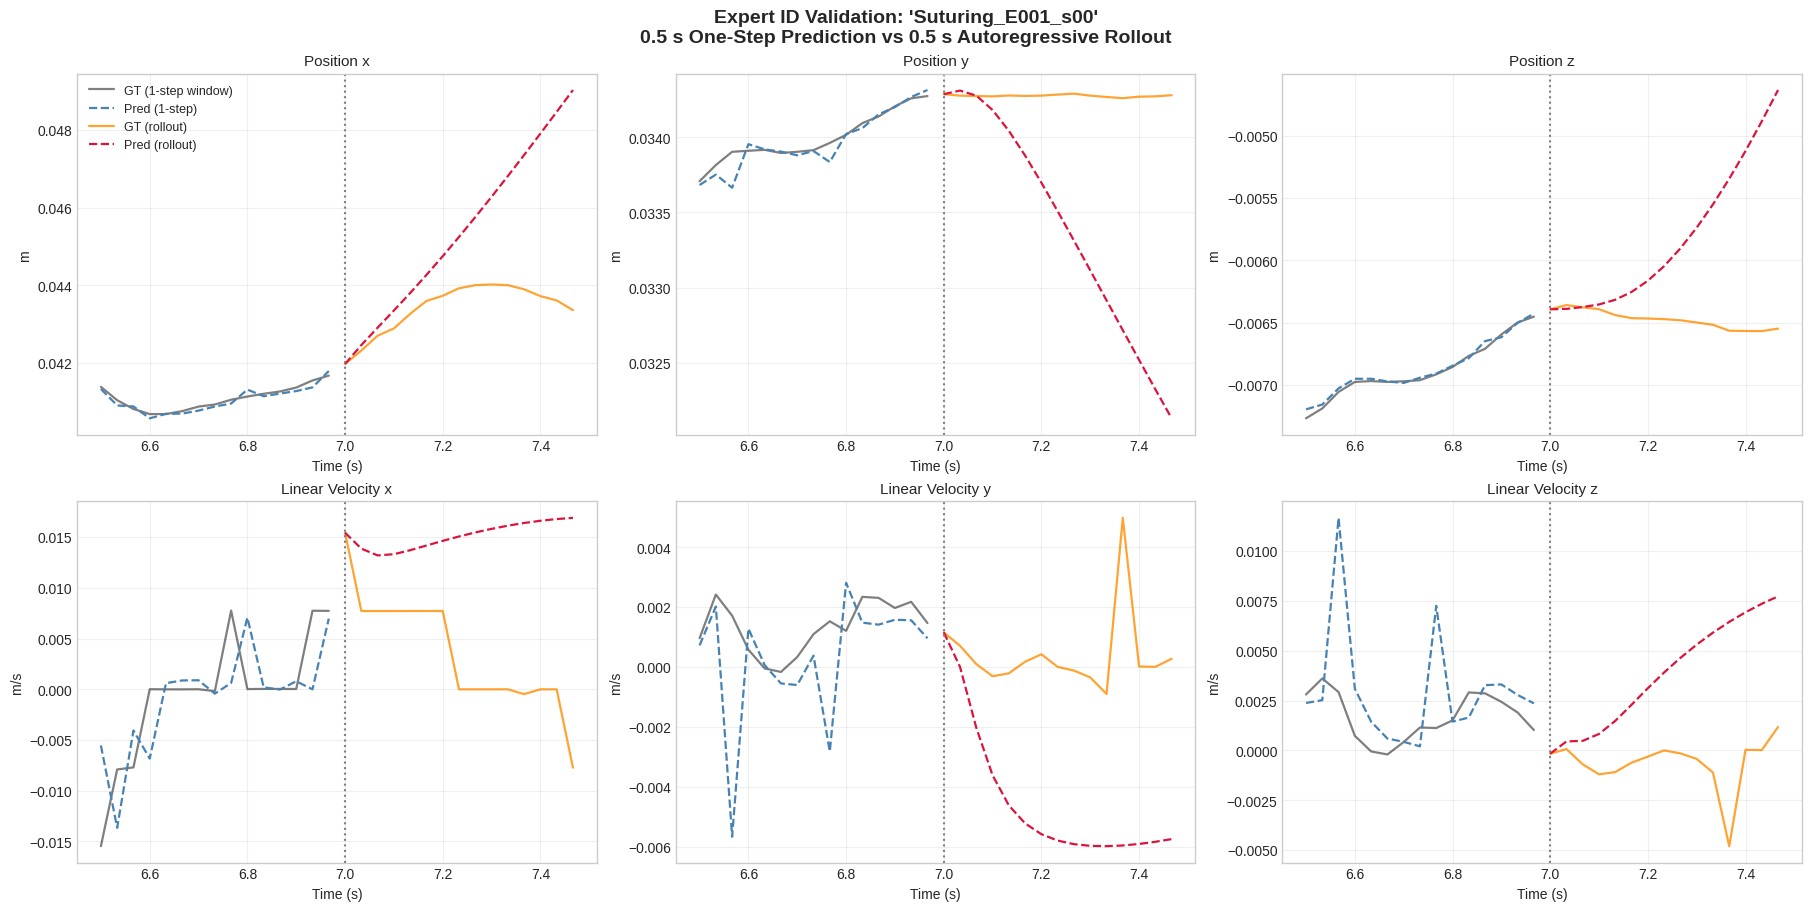

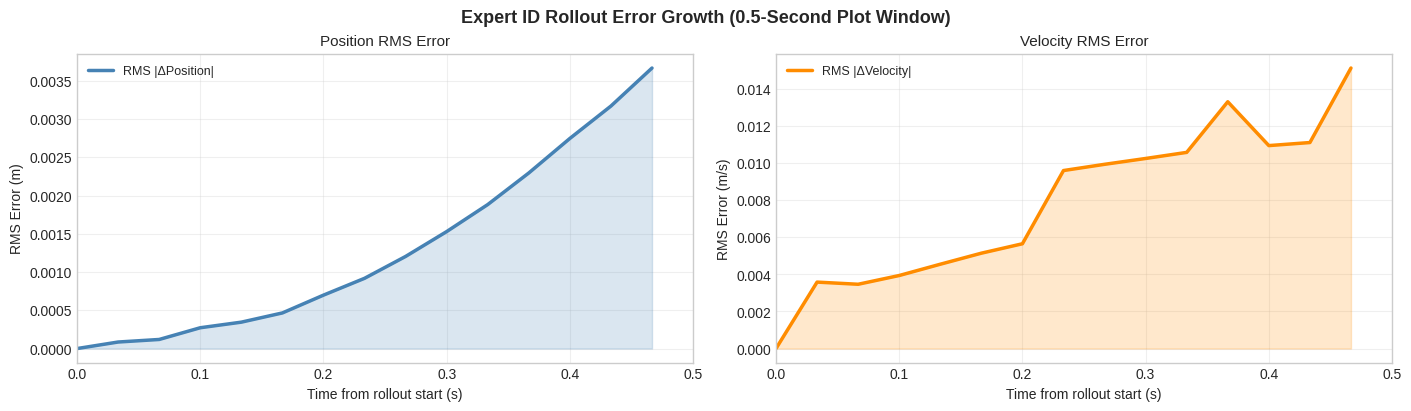


EXPERT ID ROLLOUT ANALYSIS — 30 frames (1.00s FULL)
PLOT WINDOW — 15 frames (0.50s)
Position RMS Error (FULL 1s): 4.199155e-03 m
Velocity RMS Error (FULL 1s): 9.810856e-03 m/s



In [9]:
# ── Cell 8: In-Dist: Expert Trajectories & Error Analysis
import matplotlib.pyplot as plt
import numpy as np

# =============================================================================
# 1. Model / File Label
# =============================================================================

total_systems = args.total_systems
consensus_weight = 0.001
mod_lbl = f"ts_{total_systems} wc={consensus_weight}"

# =============================================================================
# 2. Prepare Data: Expert In-Distribution (ID) Baseline
# =============================================================================

exp_ref_trial = max(exp_test, key=lambda t: len(t['states']))
exp_states = np.array(exp_ref_trial['states'])
exp_total = len(exp_states)
exp_tr_len = int(exp_total * 0.5)

horizon_frames = min(exp_total - exp_tr_len, int(1.0 / float(DT)))

exp_t_full = np.arange(exp_total) * float(DT)
exp_t_boundary = exp_tr_len * float(DT)
exp_t_tr = exp_t_full[:exp_tr_len]
exp_t_et = exp_t_full[exp_tr_len:exp_tr_len + horizon_frames]
exp_t_relative = exp_t_et - exp_t_et[0]

exp_true_tr = exp_states[:exp_tr_len]
exp_true_et = exp_states[exp_tr_len:exp_tr_len + horizon_frames]

# =============================================================================
# 3. Predictions
# =============================================================================

exp_xt_tr_raw = exp_states[:exp_tr_len - 1]
exp_pred_tr = np.asarray(eval_model(exp_xt_tr_raw))
exp_pred_tr = np.vstack([exp_states[0], exp_pred_tr])

exp_x0_test_raw = exp_states[exp_tr_len]
exp_pred_et = np.asarray(rollout_jax(eval_model, exp_x0_test_raw, horizon_frames))

exp_err_et = np.abs(exp_pred_et - exp_true_et)

labels = ['x', 'y', 'z']
trans_idx = [0, 1, 2]
linvel_idx = [6, 7, 8]

# =============================================================================
# 4. Plotting Window: Only 0.5 Second
# =============================================================================

plot_seconds = 0.5
plot_one_step_frames = min(exp_tr_len, int(plot_seconds / float(DT)))
plot_one_step_start = exp_tr_len - plot_one_step_frames

exp_t_tr_plot = exp_t_tr[plot_one_step_start:]
exp_true_tr_plot = exp_true_tr[plot_one_step_start:]
exp_pred_tr_plot = exp_pred_tr[plot_one_step_start:]

plot_rollout_frames = min(horizon_frames, int(plot_seconds / float(DT)))
exp_t_et_plot = exp_t_et[:plot_rollout_frames]
exp_t_relative_plot = exp_t_relative[:plot_rollout_frames]
exp_true_et_plot = exp_true_et[:plot_rollout_frames]
exp_pred_et_plot = exp_pred_et[:plot_rollout_frames]

# =============================================================================
# 5. Save Full ID Trajectories
# =============================================================================

np.savez(
    f'{mod_lbl}_id_expert_trajectory_data.npz',
    time_one_step=exp_t_tr_plot,
    true_one_step=exp_true_tr_plot,
    pred_one_step=exp_pred_tr_plot,
    time_rollout=exp_t_relative,
    true_rollout=exp_true_et,
    pred_rollout=exp_pred_et,
    time_rollout_plot=exp_t_relative_plot,
    true_rollout_plot=exp_true_et_plot,
    pred_rollout_plot=exp_pred_et_plot
)

# =============================================================================
# 6. Figure: Expert In-Distribution Performance
# =============================================================================

fig_e, axes_e = plt.subplots(2, 3, figsize=(18, 9), constrained_layout=True)

fig_e.suptitle(
    f"Expert ID Validation: '{exp_ref_trial['name']}'\n"
    f"0.5 s One-Step Prediction vs 0.5 s Autoregressive Rollout",
    fontsize=14,
    fontweight='bold'
)

C_GT_TR, C_GT_ET = 'black', 'darkorange'
C_PR_TR, C_PR_ET = 'steelblue', 'crimson'

for row, idxs, ylabel, kind in [
    (0, trans_idx, 'm', 'Position'),
    (1, linvel_idx, 'm/s', 'Linear Velocity')
]:
    for j in range(3):
        ax = axes_e[row, j]

        ax.plot(
            exp_t_tr_plot,
            exp_true_tr_plot[:, idxs[j]],
            color=C_GT_TR,
            lw=1.6,
            alpha=0.5,
            label='GT (1-step window)'
        )

        ax.plot(
            exp_t_tr_plot,
            exp_pred_tr_plot[:, idxs[j]],
            '--',
            color=C_PR_TR,
            lw=1.6,
            label='Pred (1-step)'
        )

        ax.plot(
            exp_t_et_plot,
            exp_true_et_plot[:, idxs[j]],
            color=C_GT_ET,
            lw=1.6,
            alpha=0.8,
            label='GT (rollout)'
        )

        ax.plot(
            exp_t_et_plot,
            exp_pred_et_plot[:, idxs[j]],
            '--',
            color=C_PR_ET,
            lw=1.6,
            label='Pred (rollout)'
        )

        ax.axvline(
            x=exp_t_boundary,
            color='gray',
            ls=':',
            lw=1.5
        )

        ax.set_title(f'{kind} {labels[j]}', fontsize=11)
        ax.set_xlabel('Time (s)')
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.3)

        if row == 0 and j == 0:
            ax.legend(fontsize=9, loc='best')

plt.show()

# =============================================================================
# 7. Figure: Aggregate RMS Error Comparison
# =============================================================================

exp_pos_err_t = np.sqrt(np.mean(exp_err_et[:, :3] ** 2, axis=1))
exp_vel_err_t = np.sqrt(np.mean(exp_err_et[:, 6:9] ** 2, axis=1))

exp_pos_err_plot = exp_pos_err_t[:plot_rollout_frames]
exp_vel_err_plot = exp_vel_err_t[:plot_rollout_frames]

fig_e5, ax_e5 = plt.subplots(
    1, 2,
    figsize=(14, 4),
    constrained_layout=True
)

fig_e5.suptitle(
    'Expert ID Rollout Error Growth (0.5-Second Plot Window)',
    fontsize=13,
    fontweight='bold'
)

for i, (err, title, ylbl, color) in enumerate([
    (exp_pos_err_plot, 'Position', 'm', 'steelblue'),
    (exp_vel_err_plot, 'Velocity', 'm/s', 'darkorange')
]):
    ax_e5[i].plot(
        exp_t_relative_plot,
        err,
        color=color,
        lw=2.5,
        label=f'RMS |Δ{title}|'
    )

    ax_e5[i].fill_between(
        exp_t_relative_plot,
        0,
        err,
        alpha=0.2,
        color=color
    )

    ax_e5[i].set_title(f'{title} RMS Error', fontsize=11)
    ax_e5[i].set_xlabel('Time from rollout start (s)')
    ax_e5[i].set_ylabel(f'RMS Error ({ylbl})')
    ax_e5[i].set_xlim(0, plot_seconds)
    ax_e5[i].grid(alpha=0.3)
    ax_e5[i].legend(fontsize=9)

plt.show()

# =============================================================================
# 8. Summary
# =============================================================================

W = 70

print(f"\n{'='*W}")
print(f"EXPERT ID ROLLOUT ANALYSIS — {horizon_frames} frames ({horizon_frames * float(DT):.2f}s FULL)")
print(f"PLOT WINDOW — {plot_rollout_frames} frames ({plot_rollout_frames * float(DT):.2f}s)")
print(f"{'='*W}")

print(f"Position RMS Error (FULL 1s): {exp_pos_err_t.mean():.6e} m")
print(f"Velocity RMS Error (FULL 1s): {exp_vel_err_t.mean():.6e} m/s")
print(f"{'='*W}\n")

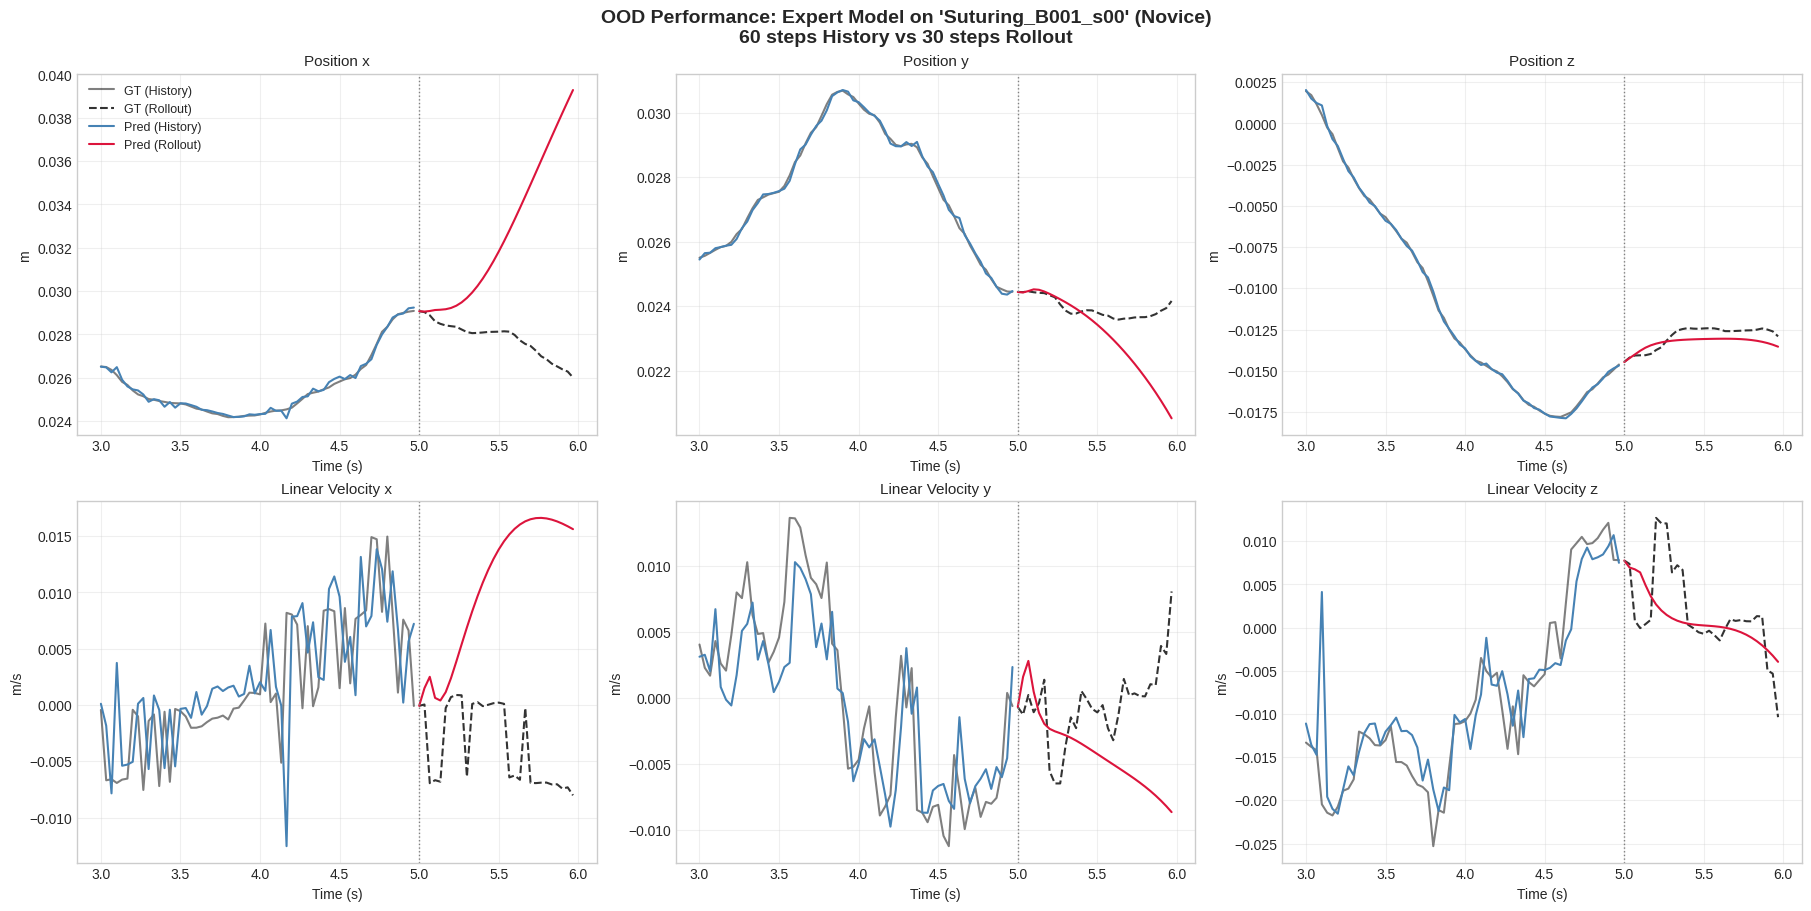

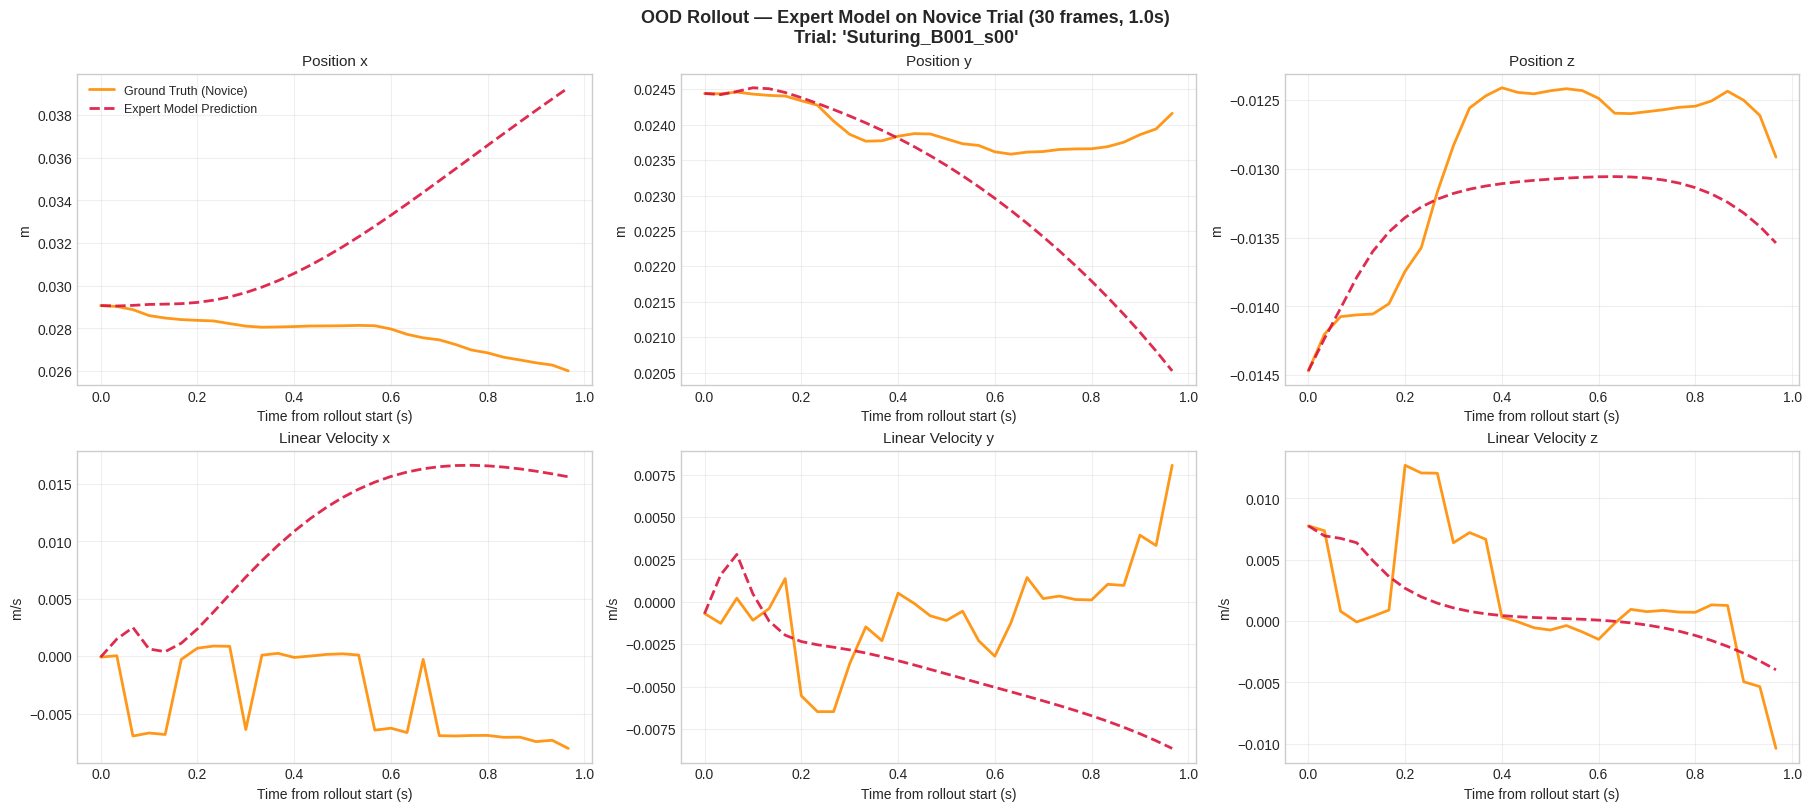

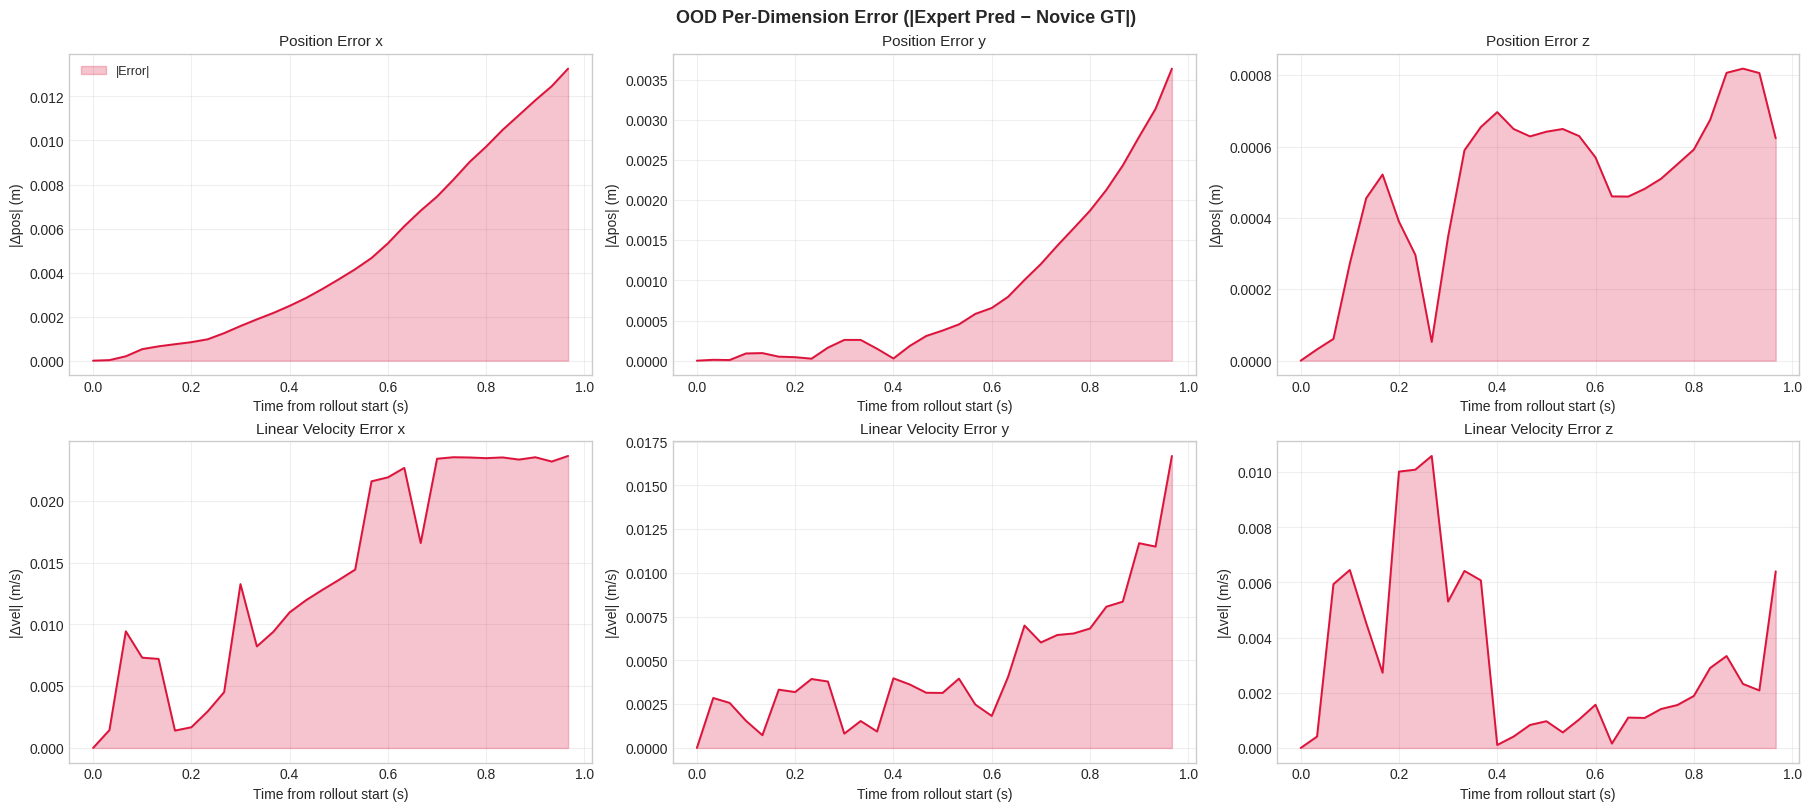

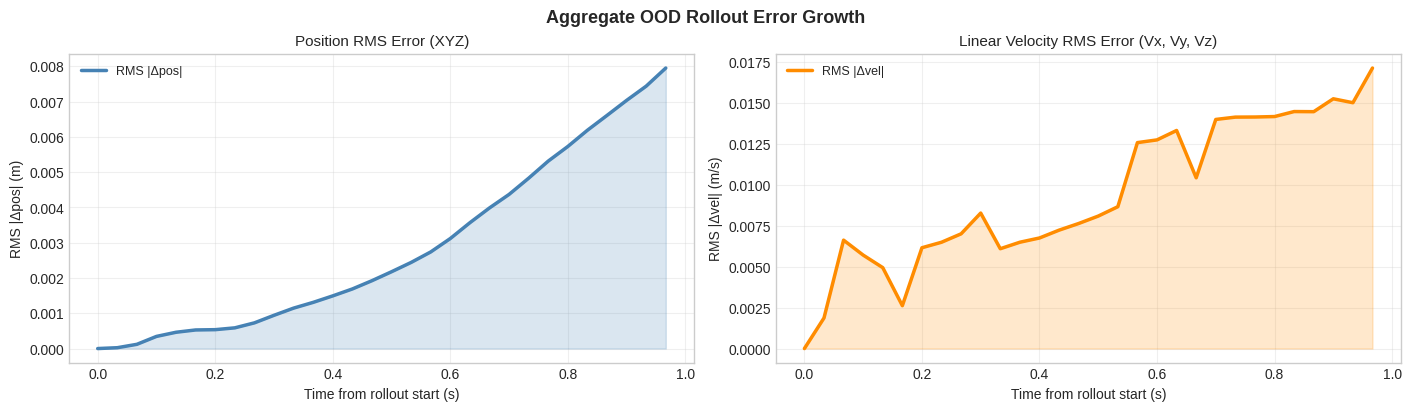


OOD ROLLOUT ANALYSIS (EXPERT -> NOVICE) — 30 frames (1.00s)
Trial: 'Suturing_B001_s00'
----------------------------------------------------------------------
Position RMS Error (m):
  Initial : 0.000000e+00
  Final   : 7.949105e-03
  Peak    : 7.949105e-03 (at t=0.97s)
  Mean    : 2.843157e-03
----------------------------------------------------------------------
Velocity RMS Error (m/s):
  Initial : 0.000000e+00
  Final   : 1.711417e-02
  Peak    : 1.711417e-02 (at t=0.97s)
  Mean    : 9.406506e-03
----------------------------------------------------------------------
Per-Dimension Final Errors at t=0.97s:
  X: Δpos = 1.326426e-02 m | Δvel = 2.364751e-02 m/s
  Y: Δpos = 3.638068e-03 m | Δvel = 1.668665e-02 m/s
  Z: Δpos = 6.233752e-04 m | Δvel = 6.405879e-03 m/s



In [10]:
# ── Cell 9: OOD Performance — Expert Model on Novice (JIGSAWS) ─────────────

import numpy as np
import matplotlib.pyplot as plt

# =============================================================================
# 1. Model / File Label
# =============================================================================

total_systems = args.total_systems
consensus_weight = 0.01
mod_lbl = f"ts_{total_systems} wc={consensus_weight}"

# =============================================================================
# 2. Prepare Data for Novice (OOD) Visualization
# =============================================================================

ref_trial = nov_segs[0]
states = np.array(ref_trial['states'])
T = len(states)

start_idx = int(T * 0.5)
n_steps_plot_hist = 60
n_steps_rollout = 30

t_full = np.arange(T) * float(DT)
t_hist = t_full[start_idx - n_steps_plot_hist:start_idx]
t_rollout = t_full[start_idx:start_idx + n_steps_rollout]

true_hist = states[start_idx - n_steps_plot_hist:start_idx]
true_rollout = states[start_idx:start_idx + n_steps_rollout]

# =============================================================================
# 3. Predictions
# =============================================================================

x_hist_raw = states[start_idx - n_steps_plot_hist - 1:start_idx - 1]
pred_hist = np.asarray(eval_model(x_hist_raw))

x0_raw = states[start_idx]
pred_rollout = np.asarray(
    rollout_jax(
        eval_model,
        x0_raw,
        n_steps_rollout
    )
)

# =============================================================================
# 4. Figure: Expert Model on Novice OOD Trajectory
# =============================================================================

labels = ['x', 'y', 'z']
trans_idx = [0, 1, 2]
linvel_idx = [6, 7, 8]

fig, axes = plt.subplots(
    2,
    3,
    figsize=(18, 9),
    constrained_layout=True
)

fig.suptitle(
    f"OOD Performance: Expert Model on '{ref_trial['name']}' (Novice)\n"
    f"{n_steps_plot_hist} steps History vs {n_steps_rollout} steps Rollout",
    fontsize=14,
    fontweight='bold'
)

C_GT = 'black'
C_PR_HIST, C_PR_ROLL = 'steelblue', 'crimson'

for row, idxs, ylabel, kind in [
    (0, trans_idx, 'm', 'Position'),
    (1, linvel_idx, 'm/s', 'Linear Velocity')
]:
    for j in range(3):
        ax = axes[row, j]

        ax.plot(
            t_hist,
            true_hist[:, idxs[j]],
            color=C_GT,
            lw=1.5,
            alpha=0.5,
            label='GT (History)'
        )

        ax.plot(
            t_rollout,
            true_rollout[:, idxs[j]],
            color=C_GT,
            lw=1.5,
            ls='--',
            alpha=0.8,
            label='GT (Rollout)'
        )

        ax.plot(
            t_hist,
            pred_hist[:, idxs[j]],
            color=C_PR_HIST,
            lw=1.5,
            label='Pred (History)'
        )

        ax.plot(
            t_rollout,
            pred_rollout[:, idxs[j]],
            color=C_PR_ROLL,
            lw=1.5,
            label='Pred (Rollout)'
        )

        ax.axvline(
            x=t_rollout[0],
            color='gray',
            ls=':',
            lw=1.0
        )

        ax.set_title(f'{kind} {labels[j]}', fontsize=11)
        ax.set_xlabel('Time (s)')
        ax.set_ylabel(ylabel)
        ax.grid(True, alpha=0.3)

        if row == 0 and j == 0:
            ax.legend(loc='best', fontsize=9)

plt.show()

# =============================================================================
# 5. OOD Rollout Alignment and Error
# =============================================================================

T_roll = len(pred_rollout)
t_relative = t_rollout - t_rollout[0]

err_rollout = np.abs(pred_rollout - true_rollout)

# =============================================================================
# 6. Save Full OOD Trajectories
# =============================================================================

np.savez(
    f'{mod_lbl}_ood_novice_trajectory_data.npz',
    time_history=t_hist,
    true_history=true_hist,
    pred_history=pred_hist,
    time_rollout=t_relative,
    true_rollout=true_rollout,
    pred_rollout=pred_rollout
)

# =============================================================================
# 7. OOD Trajectory
# =============================================================================

fig3, axes3 = plt.subplots(
    2,
    3,
    figsize=(18, 8),
    constrained_layout=True
)

fig3.suptitle(
    f"OOD Rollout — Expert Model on Novice Trial "
    f"({T_roll} frames, {T_roll * float(DT):.1f}s)\n"
    f"Trial: '{ref_trial['name']}'",
    fontsize=13,
    fontweight='bold'
)

for row, idxs, ylabel, kind in [
    (0, trans_idx, 'm', 'Position'),
    (1, linvel_idx, 'm/s', 'Linear Velocity')
]:
    for j in range(3):
        ax = axes3[row, j]

        ax.plot(
            t_relative,
            true_rollout[:, idxs[j]],
            color='darkorange',
            lw=2.0,
            alpha=0.90,
            label='Ground Truth (Novice)'
        )

        ax.plot(
            t_relative,
            pred_rollout[:, idxs[j]],
            '--',
            color='crimson',
            lw=2.0,
            alpha=0.90,
            label='Expert Model Prediction'
        )

        ax.set_title(f'{kind} {labels[j]}', fontsize=11)
        ax.set_xlabel('Time from rollout start (s)')
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.3)

        if row == 0 and j == 0:
            ax.legend(fontsize=9)

plt.show()

# =============================================================================
# 8. Per-Dimension OOD Absolute Error
# =============================================================================

fig4, axes4 = plt.subplots(
    2,
    3,
    figsize=(18, 8),
    constrained_layout=True
)

fig4.suptitle(
    "OOD Per-Dimension Error (|Expert Pred − Novice GT|)",
    fontsize=13,
    fontweight='bold'
)

for row, idxs, ylbl, kind in [
    (0, trans_idx, '|Δpos| (m)', 'Position Error'),
    (1, linvel_idx, '|Δvel| (m/s)', 'Linear Velocity Error')
]:
    for j in range(3):
        ax = axes4[row, j]

        ax.fill_between(
            t_relative,
            0,
            err_rollout[:, idxs[j]],
            color='crimson',
            alpha=0.25,
            label='|Error|'
        )

        ax.plot(
            t_relative,
            err_rollout[:, idxs[j]],
            color='crimson',
            lw=1.4
        )

        ax.set_title(f'{kind} {labels[j]}', fontsize=11)
        ax.set_xlabel('Time from rollout start (s)')
        ax.set_ylabel(ylbl)
        ax.grid(alpha=0.3)

        if row == 0 and j == 0:
            ax.legend(fontsize=9)

plt.show()

# =============================================================================
# 9. Aggregate OOD RMS Error
# =============================================================================

pos_err_t = np.sqrt(np.mean(err_rollout[:, :3] ** 2, axis=1))
vel_err_t = np.sqrt(np.mean(err_rollout[:, 6:9] ** 2, axis=1))

fig5, ax5 = plt.subplots(
    1,
    2,
    figsize=(14, 4),
    constrained_layout=True
)

fig5.suptitle(
    'Aggregate OOD Rollout Error Growth',
    fontsize=13,
    fontweight='bold'
)

ax5[0].plot(
    t_relative,
    pos_err_t,
    color='steelblue',
    lw=2.5,
    label='RMS |Δpos|'
)

ax5[0].fill_between(
    t_relative,
    0,
    pos_err_t,
    alpha=0.2,
    color='steelblue'
)

ax5[0].set_title('Position RMS Error (XYZ)', fontsize=11)
ax5[0].set_xlabel('Time from rollout start (s)')
ax5[0].set_ylabel('RMS |Δpos| (m)')
ax5[0].grid(alpha=0.3)
ax5[0].legend(fontsize=9)

ax5[1].plot(
    t_relative,
    vel_err_t,
    color='darkorange',
    lw=2.5,
    label='RMS |Δvel|'
)

ax5[1].fill_between(
    t_relative,
    0,
    vel_err_t,
    alpha=0.2,
    color='darkorange'
)

ax5[1].set_title('Linear Velocity RMS Error (Vx, Vy, Vz)', fontsize=11)
ax5[1].set_xlabel('Time from rollout start (s)')
ax5[1].set_ylabel('RMS |Δvel| (m/s)')
ax5[1].grid(alpha=0.3)
ax5[1].legend(fontsize=9)

plt.show()

# =============================================================================
# 10. Summary Statistics
# =============================================================================

W = 70

print(f"\n{'='*W}")
print(f"OOD ROLLOUT ANALYSIS (EXPERT -> NOVICE) — {T_roll} frames ({T_roll*float(DT):.2f}s)")
print(f"{'='*W}")
print(f"Trial: '{ref_trial['name']}'")

print(f"{'-'*W}")
print("Position RMS Error (m):")
print(f"  Initial : {pos_err_t[0]:.6e}")
print(f"  Final   : {pos_err_t[-1]:.6e}")
print(f"  Peak    : {pos_err_t.max():.6e} (at t={t_relative[pos_err_t.argmax()]:.2f}s)")
print(f"  Mean    : {pos_err_t.mean():.6e}")

print(f"{'-'*W}")
print("Velocity RMS Error (m/s):")
print(f"  Initial : {vel_err_t[0]:.6e}")
print(f"  Final   : {vel_err_t[-1]:.6e}")
print(f"  Peak    : {vel_err_t.max():.6e} (at t={t_relative[vel_err_t.argmax()]:.2f}s)")
print(f"  Mean    : {vel_err_t.mean():.6e}")

print(f"{'-'*W}")
print(f"Per-Dimension Final Errors at t={t_relative[-1]:.2f}s:")

for i, label in enumerate(labels):
    pos_err_final = err_rollout[-1, i]
    vel_err_final = err_rollout[-1, 6 + i]
    print(
        f"  {label.upper()}: "
        f"Δpos = {pos_err_final:.6e} m | "
        f"Δvel = {vel_err_final:.6e} m/s"
    )

print(f"{'='*W}\n")

In [11]:
# ── Cell 10: Final Summary Table ─────────────────────────────────────────────

# =============================================================================
# 1. Dataset-Wide 1-Second Rollout Metrics
# =============================================================================

def compute_dataset_rollout_error(eval_wrapper, trials, scale_array, horizon_frames=30, step_size=30):
    all_window_errors = []

    for t in trials:
        raw_states = np.array(t['states'])
        T = len(raw_states)

        for start_idx in range(0, T - horizon_frames, step_size):
            x0_raw = raw_states[start_idx]
            true_traj = raw_states[start_idx:start_idx + horizon_frames]

            pred_traj = np.asarray(
                rollout_jax(eval_wrapper, x0_raw, horizon_frames)
            )

            err = ((pred_traj - true_traj) / scale_array) ** 2
            window_mse = np.mean(err)

            if np.isnan(window_mse) or np.isinf(window_mse):
                window_mse = 1e6

            all_window_errors.append(float(window_mse))

    all_window_errors = np.array(all_window_errors)

    raw_mean = float(np.mean(all_window_errors))
    threshold = np.percentile(all_window_errors, 99.0)
    filtered_errors = all_window_errors[all_window_errors <= threshold]
    filtered_mean = float(np.mean(filtered_errors))
    outlier_percent = float(np.sum(all_window_errors > 100.0) / len(all_window_errors) * 100)

    return raw_mean, filtered_mean, outlier_percent


scale_array = np.array(state_std, dtype=np.float32)

ro_tr_mean, ro_tr_filt, ro_tr_out = compute_dataset_rollout_error(
    eval_model, exp_train, scale_array
)

ro_nt_mean, ro_nt_filt, ro_nt_out = compute_dataset_rollout_error(
    eval_model, exp_test, scale_array
)

ro_et_mean, ro_et_filt, ro_et_out = compute_dataset_rollout_error(
    eval_model, nov_segs, scale_array
)

# =============================================================================
# 2. Final Summary Metrics
# =============================================================================

gen_gap = ((mse_et_filt - mse_tr_filt) / mse_tr_filt) * 100.0 if mse_tr_filt > 0 else 0.0
eta_ratio = eta_et_filt / eta_tr_filt if eta_tr_filt > 0 else 0.0

W = 85

print(f'\n{"="*W}')
print(f'{"FINAL SUMMARY TABLE — GLNN-MASS on JIGSAWS Suturing":^{W}}')
print(f'{"="*W}')
print(f'  Model label    : {mod_lbl}')
print(f'  Data source    : REAL JIGSAWS')
print(f'  Paradigm       : Train on EXPERT, Test on NOVICE (OOD)')
print(f'  Architecture   : L-net + F-net (JAX/Flax Compiled + MASS)')
print(f'')

print(f'  One-step MSE – Expert (Train)              {mse_tr_filt:.6e}  (Outliers: {out_tr:.2f}%)')
print(f'  One-step MSE – Expert (Test, In-Dist)      {mse_nt_filt:.6e}  (Outliers: {out_nt:.2f}%)')
print(f'  One-step MSE – Novice (Test, OOD)          {mse_et_filt:.6e}  (Outliers: {out_et:.2f}%)')
print(f'  Generalization Gap (Novice vs Expert)      {gen_gap:.2f} %')
print(f'')

print(f'  1-Second Rollout MSE – Expert (Train)      {ro_tr_filt:.6e}  (Outliers: {ro_tr_out:.2f}%)')
print(f'  1-Second Rollout MSE – Expert (Test)       {ro_nt_filt:.6e}  (Outliers: {ro_nt_out:.2f}%)')
print(f'  1-Second Rollout MSE – Novice (Test)       {ro_et_filt:.6e}  (Outliers: {ro_et_out:.2f}%)')
print(f'')

print(f'  η Expert (Filtered Mean |F_nc|)            {eta_tr_filt:.6e}')
print(f'  η Novice (Filtered Mean |F_nc|)            {eta_et_filt:.6e}')
print(f'  Novice / Expert η ratio                    {eta_ratio:.2f} ×')

print(f'{"="*W}')
print(f'  Notes:')
print(f'   • Train on EXPERT subjects, test on NOVICE subjects (OOD).')
print(f'   • Rollouts bounded to 1.0 second (30 frames) to prevent open-loop drift.')
print(f'{"="*W}\n')


                 FINAL SUMMARY TABLE — GLNN-MASS on JIGSAWS Suturing                 
  Model label    : ts_4 wc=0.01
  Data source    : REAL JIGSAWS
  Paradigm       : Train on EXPERT, Test on NOVICE (OOD)
  Architecture   : L-net + F-net (JAX/Flax Compiled + MASS)

  One-step MSE – Expert (Train)              2.092043e-01  (Outliers: 0.00%)
  One-step MSE – Expert (Test, In-Dist)      2.138295e+01  (Outliers: 1.98%)
  One-step MSE – Novice (Test, OOD)          1.512175e-01  (Outliers: 0.00%)
  Generalization Gap (Novice vs Expert)      -27.72 %

  1-Second Rollout MSE – Expert (Train)      1.388302e+00  (Outliers: 0.00%)
  1-Second Rollout MSE – Expert (Test)       1.138436e+00  (Outliers: 0.00%)
  1-Second Rollout MSE – Novice (Test)       3.738193e+05  (Outliers: 37.60%)

  η Expert (Filtered Mean |F_nc|)            4.540702e-01
  η Novice (Filtered Mean |F_nc|)            1.133524e+00
  Novice / Expert η ratio                    2.50 ×
  Notes:
   • Train on EXPERT subjects, test